In [2]:
import pcdl
import matplotlib.pyplot as plt

In [3]:
output_path = "../../../../output/"

In [60]:
mcdsts = pcdl.TimeSeries(output_path)

reading: ../../../../output/PhysiCell_settings.xml
reading: ../../../../output/output00000000.xml
working on metadata ...
working on mesh data ...
reading: ../../../../output/initial_mesh0.mat
working on microenvironment data ...
reading: ../../../../output/output00000000_microenvironment0.mat
parsing: oxygen data
parsing: glucose data
parsing: acetate data
parsing: CO2 data
working on discrete cell data ...
reading: ../../../../output/output00000000_cells.mat
working on graph data ...
reading: ../../../../output/output00000000_cell_neighbor_graph.txt
reading: ../../../../output/output00000000_attached_cells_graph.txt
reading: ../../../../output/output00000000_spring_attached_cells_graph.txt
working on physiboss data ...
Warning @ pyMCDS._read_xml : physiboss file missing ../../../../output/states_00000000.csv.
done!

reading: ../../../../output/PhysiCell_settings.xml
reading: ../../../../output/output00000001.xml
working on metadata ...
working on mesh data ...
reading: ../../../../ou

inch figure size set to [6.4, 4.8].


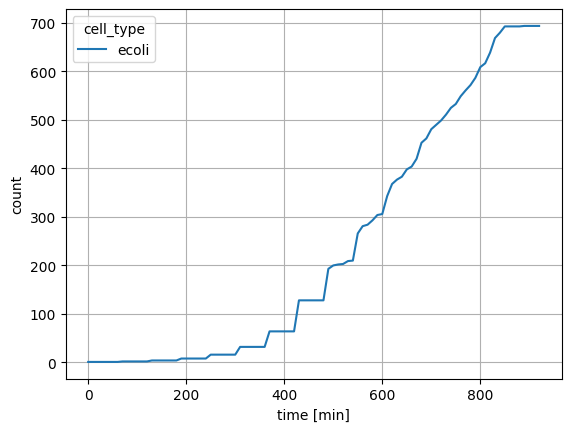

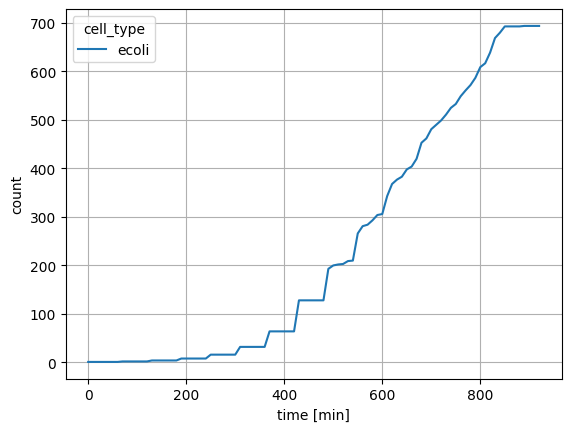

In [61]:
mcdsts.plot_timeseries("cell_type")

inch figure size set to [6.4, 4.8].


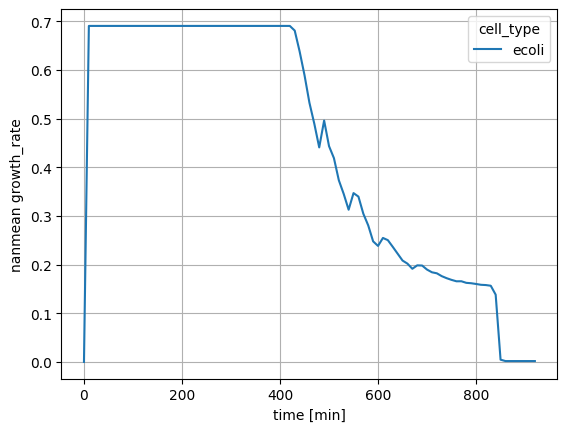

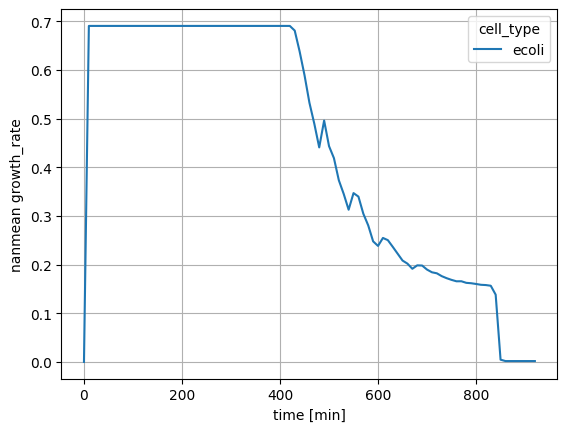

In [62]:
mcdsts.plot_timeseries("cell_type", "growth_rate")

inch figure size set to [6.4, 4.8].


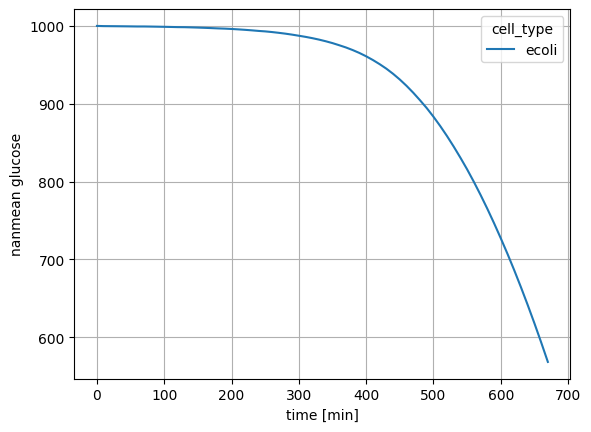

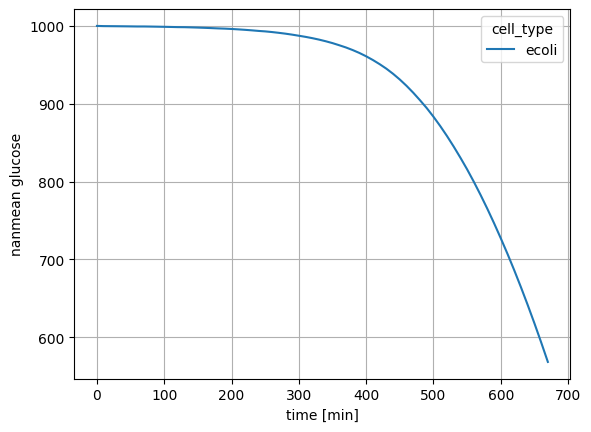

In [8]:
mcdsts.plot_timeseries("cell_type", "glucose")

inch figure size set to [6.4, 4.8].


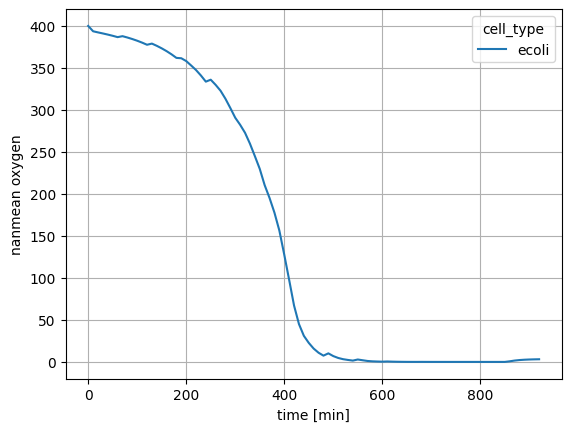

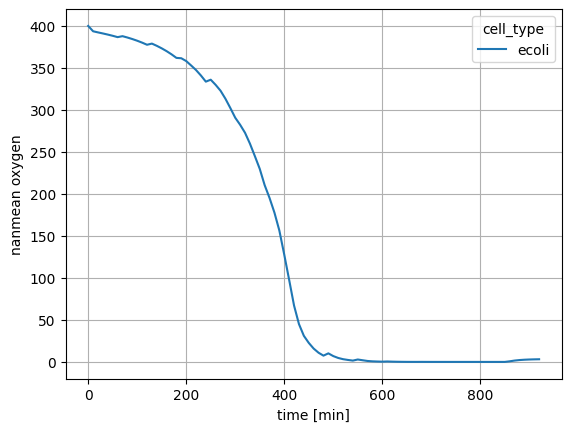

In [99]:
mcdsts.plot_timeseries("cell_type", "oxygen")

inch figure size set to [6.4, 4.8].


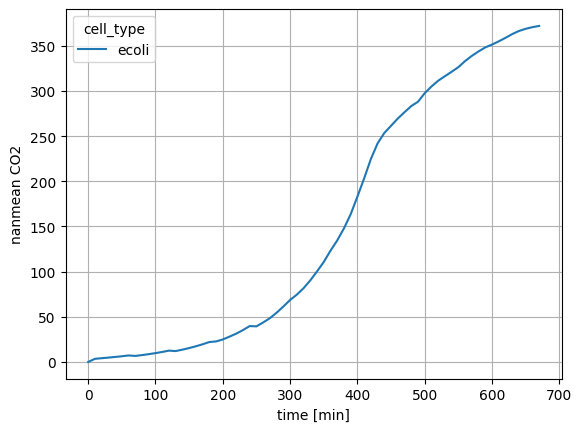

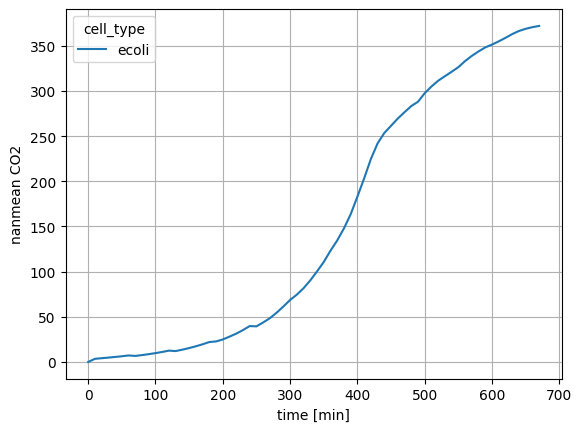

In [10]:
mcdsts.plot_timeseries("cell_type", "CO2")

In [18]:
! pip install pctk

In [42]:
from pctk import multicellds
import pandas as pd

In [52]:
# Creating a MCDS reader
reader = multicellds.MultiCellDS(output_folder=output_path)

In [53]:
data = []
for t, a in reader.microenvironment_as_matrix_iterator():
    data.append((t, a[4].sum(), a[5].sum(), a[6].sum()))

In [54]:
reader.microenvironment_columns

[('oxygen', 'dimensionless', '0'),
 ('glucose', 'dimensionless', '1'),
 ('acetate', 'dimensionless', '2'),
 ('CO2', 'dimensionless', '3')]

<Axes: xlabel='time'>

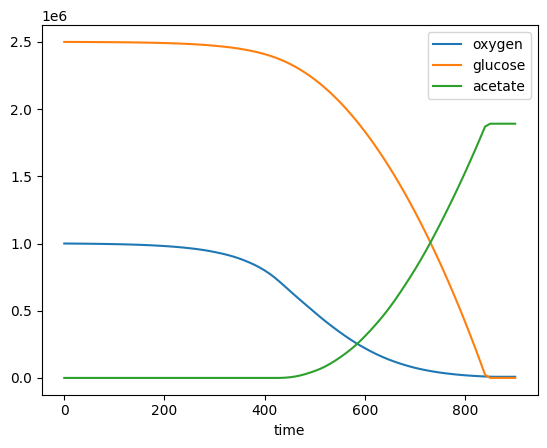

In [55]:
d = pd.DataFrame(data=data, columns=["time", "oxygen", "glucose", "acetate"]).set_index("time")
d.plot()

In [93]:
data = []
for t, a in reader.cells_as_matrix_iterator():
    data.append((t, a[:,-2].mean(), a.shape[0], a[:,4].sum()))

<Axes: xlabel='time'>

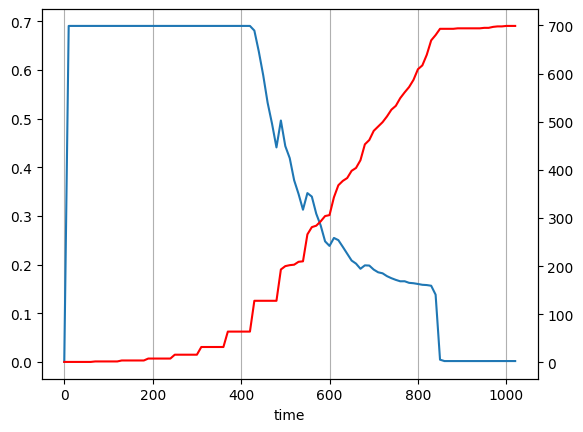

In [94]:
d = pd.DataFrame(data=data, columns=["time", "growth_rate", "n_cells", "total_biomass"]).set_index("time")
ax = d["growth_rate"].plot()
ax.grid(axis="x")
ax = ax.twinx()
d["n_cells"].plot(ax=ax, c="red")

<Axes: xlabel='time'>

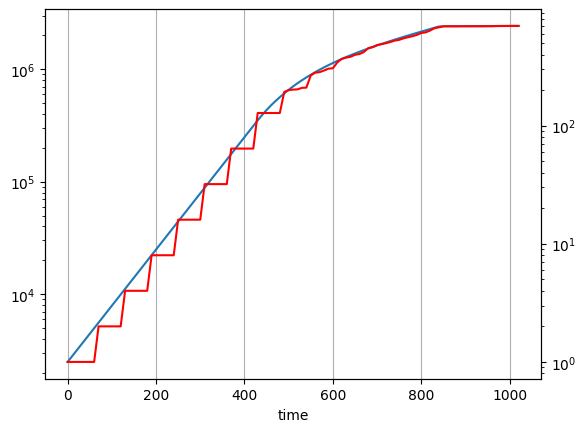

In [98]:
ax = d["total_biomass"].plot()
ax.grid(axis="x")
ax.set_yscale("log")
ax = ax.twinx()
ax.set_yscale("log")
d["n_cells"].plot(ax=ax, c="red")

In [91]:
reader.cell_columns

['ID',
 'x_position',
 'y_position',
 'z_position',
 'total_volume',
 'cell_type',
 'cycle_model',
 'current_phase',
 'elapsed_time_in_phase',
 'nuclear_volume',
 'cytoplasmic_volume',
 'fluid_fraction',
 'calcified_fraction',
 'x_orientation',
 'y_orientation',
 'z_orientation',
 'polarity',
 'x_velocity',
 'y_velocity',
 'z_velocity',
 'pressure',
 'number_of_nuclei',
 'total_attack_time',
 'contact_with_basement_membrane',
 'current_cycle_phase_exit_rate',
 'elapsed_time_in_phase',
 'dead',
 'current_death_model',
 'x_death_rates',
 'y_death_rates',
 'cytoplasmic_biomass_change_rate',
 'nuclear_biomass_change_rate',
 'fluid_change_rate',
 'calcification_rate',
 'target_solid_cytoplasmic',
 'target_solid_nuclear',
 'target_fluid_fraction',
 'radius',
 'nuclear_radius',
 'surface_area',
 'cell_cell_adhesion_strength',
 'cell_BM_adhesion_strength',
 'cell_cell_repulsion_strength',
 'cell_BM_repulsion_strength',
 'x_cell_adhesion_affinities',
 'y_cell_adhesion_affinities',
 'relative_ma